In [1]:
!pip uninstall -y tensorflow keras pennylane imbalanced-learn
!pip install tensorflow==2.15.0 keras==2.15.0 pennylane==0.39 imbalanced-learn
!pip install tf-explain

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Found existing installation: keras 3.5.0
Uninstalling keras-3.5.0:
  Successfully uninstalled keras-3.5.0
Found existing installation: imbalanced-learn 0.12.4
Uninstalling imbalanced-learn-0.12.4:
  Successfully uninstalled imbalanced-learn-0.12.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81

In [2]:
# =======================
# IMPORT REQUIRED PACKAGES
# =======================
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Quantum imports
import pennylane as qml

# For plotting and evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from PIL import Image
from tf_explain.core.grad_cam import GradCAM

# =======================
# SET RANDOM SEEDS FOR REPRODUCIBILITY
# =======================
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# =======================
# DATASET PREPARATION (assume already done)
# =======================
base_dataset_path = "/kaggle/input/oral-diseases"  # Adjust if needed
class_names = [
    "Calculus",
    "Data caries",
    "Gingivitis",
    "Mouth Ulcer",
    "ToothDiscoloration",
    "Hypodentia"
]
num_classes = len(class_names)

# Mapping from class name to folder path (adjust these as per your dataset)
cls_folder_map = {
    "Calculus": "Calculus/Calculus",
    "Data caries": "Data caries/Data caries/caries orignal data set/done",
    "Gingivitis": "Gingivitis/Gingivitis",
    "Mouth Ulcer": "Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset",
    "ToothDiscoloration": "Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset",
    "Hypodentia": "hypodontia/hypodontia"
}

working_dir = "/kaggle/working/"
dataset_dir = os.path.join(working_dir, "dataset")
os.makedirs(dataset_dir, exist_ok=True)

for cls in class_names:
    src = os.path.join(base_dataset_path, cls_folder_map[cls])
    dst = os.path.join(dataset_dir, cls)
    shutil.copytree(src, dst, dirs_exist_ok=True)
print("All classes copied into local 'dataset' folder!")

# Create directories for train, validation, and test splits
train_dir = os.path.join(working_dir, "train")
val_dir   = os.path.join(working_dir, "val")
test_dir  = os.path.join(working_dir, "test")
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)
    for cls in class_names:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Split each class into 70% train, 15% validation, and 15% test
for cls in class_names:
    class_path = os.path.join(dataset_dir, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    n_total = len(images)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    train_files = images[:n_train]
    val_files   = images[n_train:n_train + n_val]
    test_files  = images[n_train + n_val:]
    
    for f in train_files:
        shutil.move(os.path.join(class_path, f), os.path.join(train_dir, cls, f))
    for f in val_files:
        shutil.move(os.path.join(class_path, f), os.path.join(val_dir, cls, f))
    for f in test_files:
        shutil.move(os.path.join(class_path, f), os.path.join(test_dir, cls, f))
print("Train/Val/Test split completed!")

# =======================
# DATA AUGMENTATION & GENERATORS
# =======================
image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# =======================
# QUANTUM LAYER DEFINITION
# =======================
num_qubits = 6
num_layers = 6  # Number of entanglement repetitions
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, interface='tf', batching=True)
def quantum_circuit(inputs, weights):
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    for i in range(num_qubits):
        qml.RY(inputs[:, i], wires=i)
    for layer in range(num_layers):
        for i in range(num_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
        for i in range(num_qubits - 1):
            qml.CZ(wires=[i, i + 1])
        qml.CZ(wires=[num_qubits - 1, 0])
        for i in range(num_qubits):
            qml.RZ(weights[layer, i, 1], wires=i)
    for i in range(num_qubits):
        qml.RX(weights[num_layers, i, 0], wires=i)
        qml.Hadamard(wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

weight_shapes = {"weights": (num_layers + 1, num_qubits, 2)}
quantum_layer = qml.qnn.KerasLayer(
    quantum_circuit, 
    weight_shapes, 
    output_dim=num_qubits,
    name="quantum_layer"
)

# =======================
# FUSION-BASED CNN (CLASSICAL BACKBONE) FROM PDF
# =======================
# Import additional pre-trained models
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB2, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout, concatenate

# Input layer for the hybrid model
inputs = Input(shape=(image_size[0], image_size[1], 3))

# Branch 1: EfficientNet-B0
base_model1 = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
x1 = GlobalAveragePooling2D()(base_model1.output)

# Branch 2: EfficientNet-B2
base_model2 = EfficientNetB2(weights='imagenet', include_top=False, input_tensor=inputs)
x2 = GlobalAveragePooling2D()(base_model2.output)

# Branch 3: ResNet50 (from the PDF)
base_model3 = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
x3 = GlobalAveragePooling2D()(base_model3.output)

# Fuse the features from the three networks
fused_features = concatenate([x1, x2, x3])
fused_features = BatchNormalization()(fused_features)
fused_features = Dense(512, activation='relu')(fused_features)
fused_features = Dropout(0.5)(fused_features)
# Reduce to the dimension matching the number of qubits using tanh activation
pre_quantum = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(fused_features)

# =======================
# HYBRID QUANTUM-CLASSICAL MODEL
# =======================
# Pass the fused classical features through the quantum layer
x = quantum_layer(pre_quantum)
# Final classification layer with softmax activation
outputs = Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=inputs, outputs=outputs)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

# =======================
# TRAINING THE MODEL
# =======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=100,  # Adjust epochs as needed
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# =======================
# EVALUATE THE MODEL ON THE TEST SET
# =======================
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# =======================
# ADDITIONAL ANALYSIS & MODEL INTERPRETABILITY
# =======================
# Confusion Matrix & Classification Report
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names_list = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_list))

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

# Grad-CAM Visualization for Feature Importance (unchanged)
def visualize_grad_cam(image_paths, model, class_names, target_layer_name="conv5_block3_out"):
    for image_path in image_paths:
        image_orig = Image.open(image_path).convert("RGB")
        image_resized = image_orig.resize((image_size[0], image_size[1]))
        image_array = np.array(image_resized)
        input_tensor = image_array.astype(np.float32) / 255.0
        input_tensor = np.expand_dims(input_tensor, axis=0)
        
        preds = model.predict(input_tensor)
        predicted_class_index = np.argmax(preds[0])
        predicted_class = class_names[predicted_class_index]
        true_class = os.path.basename(os.path.dirname(image_path))
        
        explainer = GradCAM()
        data = (input_tensor, None)
        with tf.device('/CPU:0'):
            cam_grid = explainer.explain(data, model, class_index=predicted_class_index, layer_name=target_layer_name)
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_array / 255.0)
        plt.title(f"True: {true_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(cam_grid)
        plt.title(f"Predicted: {predicted_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

def get_random_images_from_folders(base_folder, num_images_per_folder=2):
    image_paths = []
    subfolders = [f.path for f in os.scandir(base_folder) if f.is_dir()]
    for subfolder in subfolders:
        images = [os.path.join(subfolder, f) for f in os.listdir(subfolder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 0:
            selected = np.random.choice(images, min(num_images_per_folder, len(images)), replace=False)
            image_paths.extend(selected)
    return image_paths

base_test_folder = test_dir
random_test_images = get_random_images_from_folders(base_test_folder, num_images_per_folder=2)
print("Random test images selected for Grad-CAM visualization:")
print(random_test_images)
visualize_grad_cam(random_test_images, model, class_names_list, target_layer_name="conv5_block3_out")

# =======================
# t-SNE Visualization of Decision Boundaries
# =======================
feature_extractor = models.Model(inputs=model.input, outputs=model.get_layer("pre_quantum_dense").output)
features = feature_extractor.predict(test_generator)
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_true, cmap='jet', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of Decision Boundaries (Pre-Quantum Features)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# =======================
# ROC CURVE CODE FOR MULTICLASS EVALUATION
# =======================
# Convert true labels to one-hot encoding
y_true_onehot = label_binarize(y_true, classes=range(num_classes))
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for {class_names_list[i]} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Each Class')
plt.legend(loc="lower right")
plt.show()


All classes copied into local 'dataset' folder!
Train/Val/Test split completed!
Found 3892 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Found 840 images belonging to 6 classes.


/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


94765736/94765736 [==============================] - 0s 0us/step


ValueError: The name "stem_conv_pad" is used 2 times in the model. All layer names should be unique.

Found 3892 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Found 840 images belonging to 6 classes.
219055592/219055592 [==============================] - 1s 0us/step
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 111, 111, 32)         864       ['input_4[0][0]']             
                                                                                                  
 batch_normalization_2 (Bat  (None, 111, 111, 32)         96        ['conv2d[0][0]']              
 chNormalization)                                                                                 


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


122/122 [==============================] - 370s 3s/step - loss: 1.3817 - accuracy: 0.5573 - val_loss: 1.2811 - val_accuracy: 0.6558 - lr: 1.0000e-04
Epoch 2/100
122/122 [==============================] - ETA: 0s - loss: 1.2421 - accuracy: 0.6554
Epoch 2: val_loss improved from 1.28109 to 1.21520, saving model to best_model.h5
122/122 [==============================] - 309s 3s/step - loss: 1.2421 - accuracy: 0.6554 - val_loss: 1.2152 - val_accuracy: 0.6643 - lr: 1.0000e-04
Epoch 3/100
122/122 [==============================] - ETA: 0s - loss: 1.1698 - accuracy: 0.6732
Epoch 3: val_loss improved from 1.21520 to 1.14722, saving model to best_model.h5
122/122 [==============================] - 309s 3s/step - loss: 1.1698 - accuracy: 0.6732 - val_loss: 1.1472 - val_accuracy: 0.7040 - lr: 1.0000e-04
Epoch 4/100
122/122 [==============================] - ETA: 0s - loss: 1.1097 - accuracy: 0.7079
Epoch 4: val_loss improved from 1.14722 to 1.13055, saving model to best_model.h5
122/122 [=======

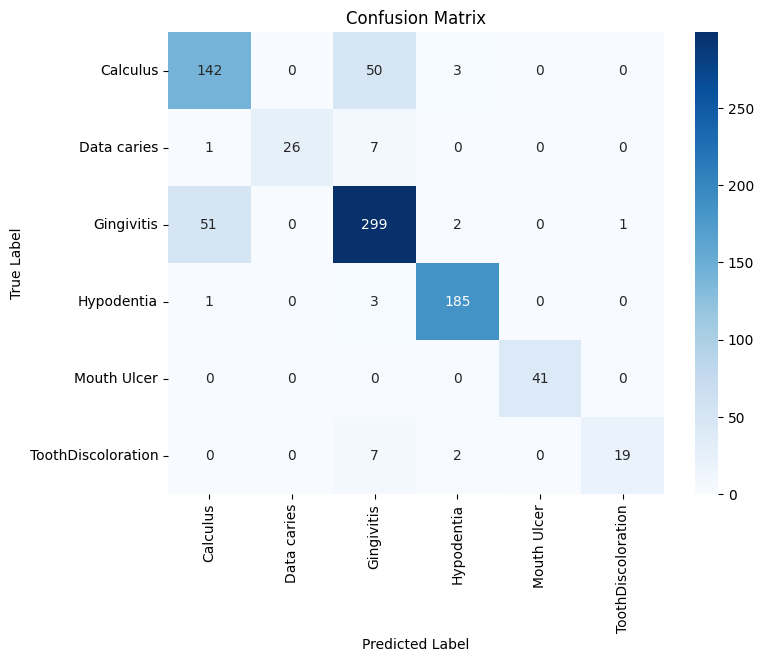

Classification Report:
                    precision    recall  f1-score   support

          Calculus       0.73      0.73      0.73       195
       Data caries       1.00      0.76      0.87        34
        Gingivitis       0.82      0.85      0.83       353
        Hypodentia       0.96      0.98      0.97       189
       Mouth Ulcer       1.00      1.00      1.00        41
ToothDiscoloration       0.95      0.68      0.79        28

          accuracy                           0.85       840
         macro avg       0.91      0.83      0.86       840
      weighted avg       0.85      0.85      0.85       840



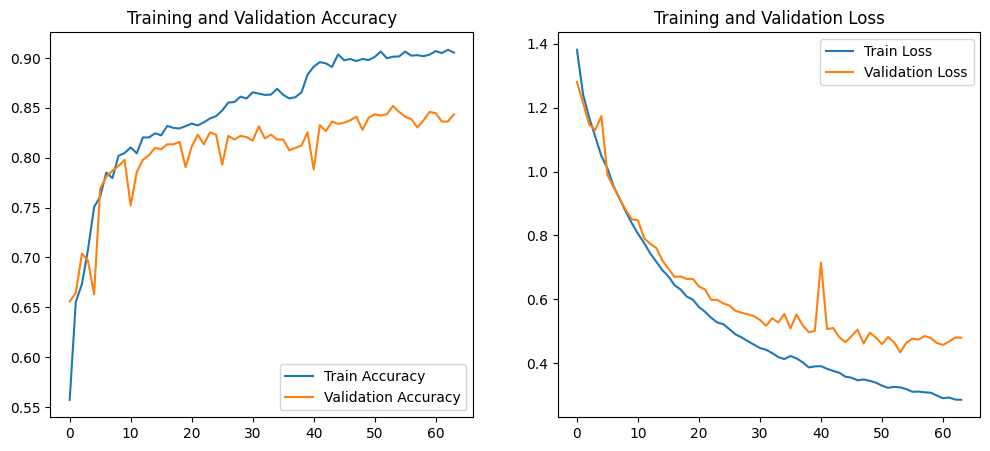

Random test images selected for Grad-CAM visualization:
['/kaggle/working/test/Data caries/138.jpg', '/kaggle/working/test/Data caries/111.jpg', '/kaggle/working/test/Gingivitis/(1881).jpg', '/kaggle/working/test/Gingivitis/(1999).jpg', '/kaggle/working/test/Calculus/(340).jpg', '/kaggle/working/test/Calculus/(178).jpg', '/kaggle/working/test/ToothDiscoloration/66.jpg', '/kaggle/working/test/ToothDiscoloration/59.jpg', '/kaggle/working/test/Hypodentia/(271).jpg', '/kaggle/working/test/Hypodentia/(167).JPG', '/kaggle/working/test/Mouth Ulcer/63.jpg', '/kaggle/working/test/Mouth Ulcer/192.jpg']
1/1 [==============================] - 1s 906ms/step


ValueError: No such layer: conv5_block3_out. Existing layers are: ['input_4', 'conv2d', 'batch_normalization_2', 'activation', 'conv2d_1', 'batch_normalization_3', 'activation_1', 'conv2d_2', 'batch_normalization_4', 'activation_2', 'max_pooling2d', 'conv2d_3', 'batch_normalization_5', 'activation_3', 'conv2d_4', 'batch_normalization_6', 'activation_4', 'max_pooling2d_1', 'conv2d_8', 'batch_normalization_10', 'activation_8', 'conv2d_6', 'conv2d_9', 'batch_normalization_8', 'batch_normalization_11', 'activation_6', 'activation_9', 'average_pooling2d', 'conv2d_5', 'conv2d_7', 'conv2d_10', 'conv2d_11', 'batch_normalization_7', 'batch_normalization_9', 'batch_normalization_12', 'batch_normalization_13', 'activation_5', 'activation_7', 'activation_10', 'activation_11', 'mixed_5b', 'conv2d_15', 'batch_normalization_17', 'activation_15', 'conv2d_13', 'conv2d_16', 'batch_normalization_15', 'batch_normalization_18', 'activation_13', 'activation_16', 'conv2d_12', 'conv2d_14', 'conv2d_17', 'batch

In [5]:
# =======================
# DATA AUGMENTATION & GENERATORS
# =======================
image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# =======================
# MODEL ARCHITECTURE: HYBRID QUANTUM-CLASSICAL MODEL
# (Classical backbone replaced with InceptionResNetV2 based on the provided PDF)
# =======================
num_qubits = 6
num_layers = 6  # Number of entanglement repetitions
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, interface='tf', batching=True)
def quantum_circuit(inputs, weights):
    # Apply Hadamard gates to each qubit (batched)
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    # Embed classical data using RY gates
    for i in range(num_qubits):
        qml.RY(inputs[:, i], wires=i)
    # Entanglement layers with parameterized rotations
    for layer in range(num_layers):
        # RY rotations
        for i in range(num_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
        # Entanglement using CZ gates
        for i in range(num_qubits - 1):
            qml.CZ(wires=[i, i + 1])
        qml.CZ(wires=[num_qubits - 1, 0])
        # RZ rotations
        for i in range(num_qubits):
            qml.RZ(weights[layer, i, 1], wires=i)
    # Final rotation and measurement preparation
    for i in range(num_qubits):
        qml.RX(weights[num_layers, i, 0], wires=i)
        qml.Hadamard(wires=i)
    # Return expectation values for each qubit (batched)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

# Define weight shapes to accommodate layers + final rotation
weight_shapes = {"weights": (num_layers + 1, num_qubits, 2)}
quantum_layer = qml.qnn.KerasLayer(
    quantum_circuit, 
    weight_shapes, 
    output_dim=num_qubits,
    name="quantum_layer"
)

# --- Classical Backbone: InceptionResNetV2 as feature extractor ---
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load InceptionResNetV2 with ImageNet weights, removing the top fully-connected layers
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Reduce to features matching the number of qubits (using tanh activation)
x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)

# --- Hybrid Quantum-Classical Model ---
x = quantum_layer(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

# =======================
# TRAINING THE MODEL
# =======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=100,  # Adjust epochs as needed
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# =======================
# EVALUATE THE MODEL ON THE TEST SET
# =======================
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# =======================
# ADDITIONAL ANALYSIS & MODEL INTERPRETABILITY
# =======================

# -- Confusion Matrix & Classification Report --
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names_list = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_list))

# -- Plot Training History --
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

# -- Grad-CAM Visualization for Feature Importance --
def visualize_grad_cam(image_paths, model, class_names, target_layer_name="conv5_block3_out"):
    """
    Generates and displays Grad-CAM visualizations for a list of images.
    """
    for image_path in image_paths:
        image_orig = Image.open(image_path).convert("RGB")
        image_resized = image_orig.resize((image_size[0], image_size[1]))
        image_array = np.array(image_resized)
        input_tensor = image_array.astype(np.float32) / 255.0
        input_tensor = np.expand_dims(input_tensor, axis=0)
        
        preds = model.predict(input_tensor)
        predicted_class_index = np.argmax(preds[0])
        predicted_class = class_names[predicted_class_index]
        true_class = os.path.basename(os.path.dirname(image_path))
        
        explainer = GradCAM()
        data = (input_tensor, None)
        with tf.device('/CPU:0'):
            cam_grid = explainer.explain(data, model, class_index=predicted_class_index, layer_name=target_layer_name)
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_array / 255.0)
        plt.title(f"True: {true_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(cam_grid)
        plt.title(f"Predicted: {predicted_class}", fontsize=18,
                  color='green' if true_class == predicted_class else 'red')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

def get_random_images_from_folders(base_folder, num_images_per_folder=2):
    image_paths = []
    subfolders = [f.path for f in os.scandir(base_folder) if f.is_dir()]
    for subfolder in subfolders:
        images = [os.path.join(subfolder, f) for f in os.listdir(subfolder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(images) > 0:
            selected = np.random.choice(images, min(num_images_per_folder, len(images)), replace=False)
            image_paths.extend(selected)
    return image_paths

base_test_folder = test_dir
random_test_images = get_random_images_from_folders(base_test_folder, num_images_per_folder=2)
print("Random test images selected for Grad-CAM visualization:")
print(random_test_images)
visualize_grad_cam(random_test_images, model, class_names_list, target_layer_name="conv5_block3_out")

# -- t-SNE Visualization of Decision Boundaries --
# Extract features from the pre-quantum dense layer ("pre_quantum_dense")
feature_extractor = models.Model(inputs=model.input, outputs=model.get_layer("pre_quantum_dense").output)
features = feature_extractor.predict(test_generator)
# Use t-SNE to reduce features to 2D
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_true, cmap='jet', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of Decision Boundaries (Pre-Quantum Features)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# =======================
# ROC CURVE VISUALIZATION
# =======================
# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves for all classes and micro-average
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

colors = ['aqua', 'darkorange', 'cornflowerblue', 'limegreen', 'purple', 'red']
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_names_list[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multi-Class Classification')
plt.legend(loc="lower right")
plt.show()

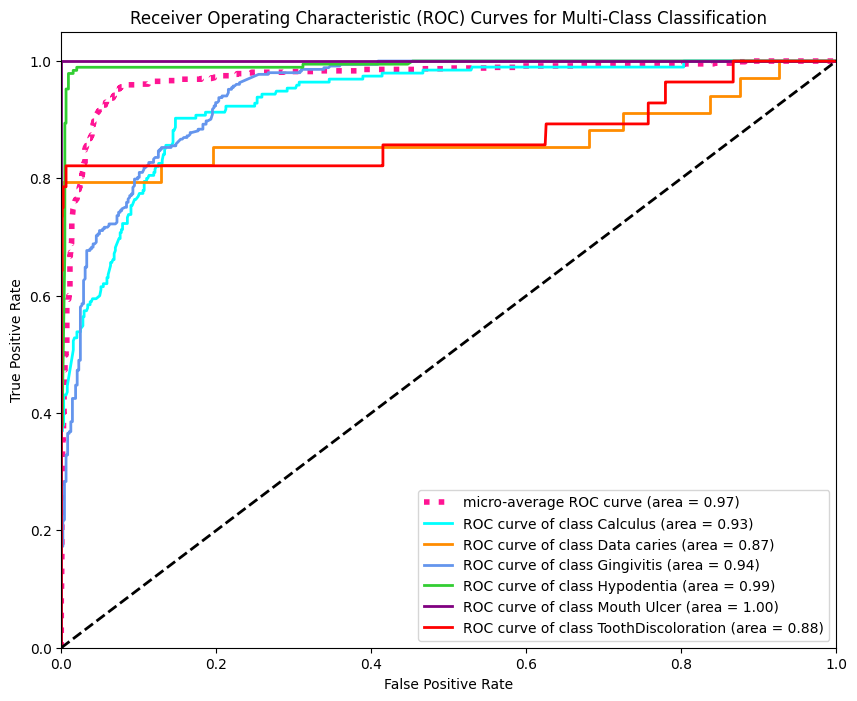

In [6]:
# =======================
# ROC CURVE VISUALIZATION
# =======================
# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves for all classes and micro-average
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

colors = ['aqua', 'darkorange', 'cornflowerblue', 'limegreen', 'purple', 'red']
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_names_list[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multi-Class Classification')
plt.legend(loc="lower right")
plt.show()

27/27 [==============================] - 7s 151ms/step


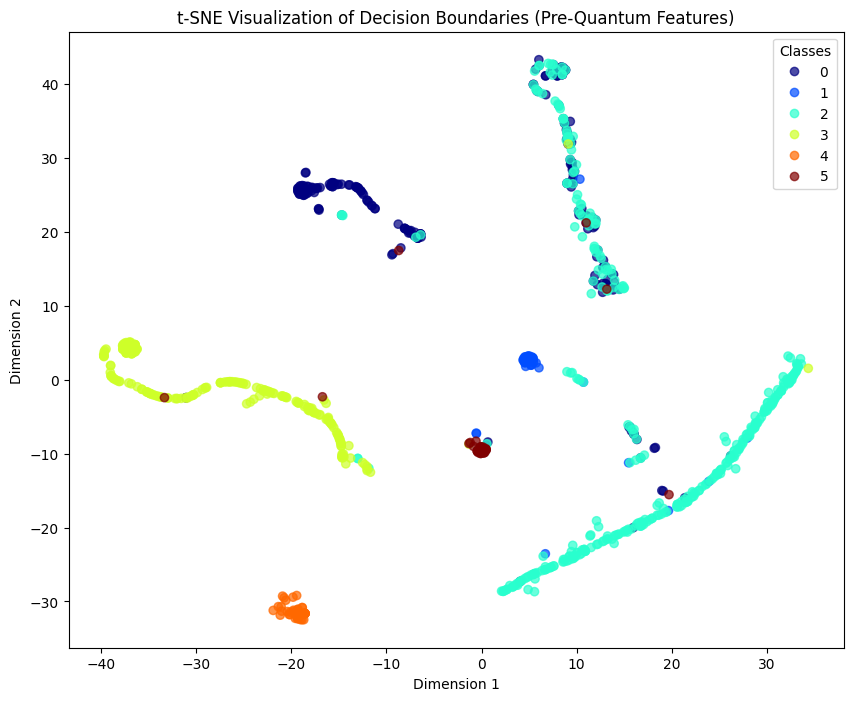

In [7]:
# -- t-SNE Visualization of Decision Boundaries --
# Extract features from the pre-quantum dense layer ("pre_quantum_dense")
feature_extractor = models.Model(inputs=model.input, outputs=model.get_layer("pre_quantum_dense").output)
features = feature_extractor.predict(test_generator)
# Use t-SNE to reduce features to 2D
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_true, cmap='jet', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of Decision Boundaries (Pre-Quantum Features)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

27/27 [==============================] - 7s 153ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


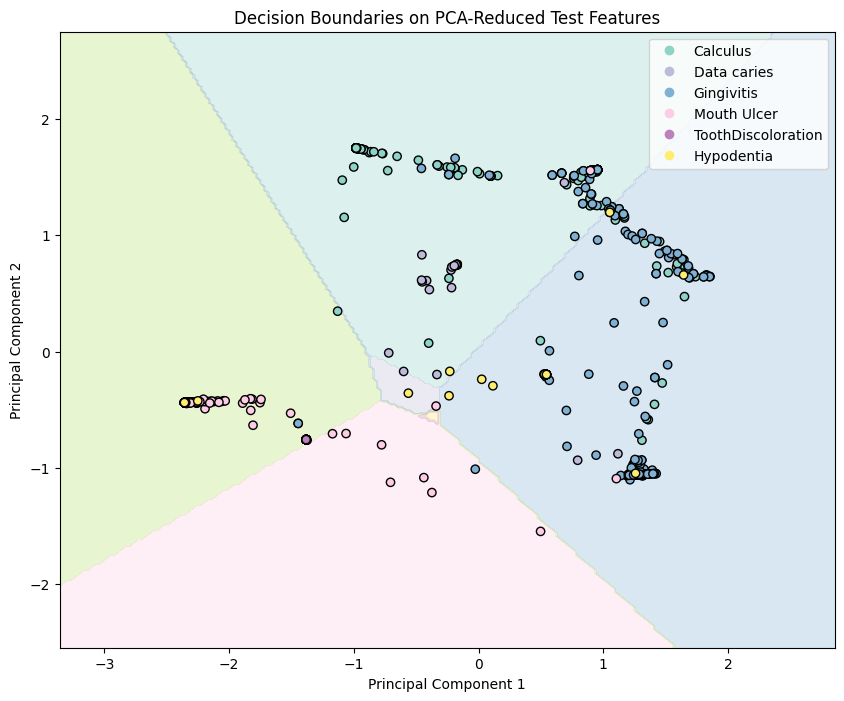

In [8]:
# 2. Visualizing Decision Boundaries via PCA
# ------------------------------

# Note:
# Directly plotting decision boundaries in high-dimensional spaces is impractical.
# Instead, we extract features from an intermediate layer (e.g., the "pre_quantum_dense" layer),
# reduce their dimension with PCA to 2D, and then train a surrogate classifier (here, logistic regression)
# to approximate the decision boundary for visualization.

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Build an intermediate model to extract features.
# Make sure you use the layer name right where you want to tap into the model.
feature_extractor = tf.keras.models.Model(inputs=model.input,
                                          outputs=model.get_layer("pre_quantum_dense").output)

# Extract features from the test set (or a subset that fits into memory)
features = feature_extractor.predict(test_generator, verbose=1)

# Apply PCA to reduce dimensions to 2 for visualization.
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# For the decision boundaries, we are using the true class labels from the test set.
# (They should be in the same order as the features due to the use of reset() above.)
labels = test_generator.classes

# Train a simple classifier on the 2D features.
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
clf.fit(features_2d, labels)

# Create a meshgrid based on the 2D PCA space.
x_min, x_max = features_2d[:, 0].min() - 1, features_2d[:, 0].max() + 1
y_min, y_max = features_2d[:, 1].min() - 1, features_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict the class for each point in the meshgrid.
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries along with the test features.
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, 
                      edgecolor='k', cmap=plt.cm.Set3)

plt.title("Decision Boundaries on PCA-Reduced Test Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.show()

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
from IPython.display import FileLink, display

# Reset the test generator for consistent ordering
test_generator.reset()

# Generate predictions on the test set
y_pred = model.predict(test_generator, verbose=1)

# True labels (as integers corresponding to class indices)
y_true = test_generator.classes

# Binarize the true labels for multi-class ROC computation
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve datapoints for each class and save to CSV
for i, cls_name in enumerate(class_names):
    # Compute false positive rate (fpr) and true positive rate (tpr)
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    
    # Create a DataFrame with fpr and tpr
    df_roc = pd.DataFrame({'FPR': fpr, 'TPR': tpr})
    
    # Save CSV file for this class
    csv_filename = f"roc_curve_{cls_name.replace(' ', '_')}.csv"
    df_roc.to_csv(csv_filename, index=False)
    
    print(f"ROC curve datapoints for {cls_name} saved in '{csv_filename}'")
    
    # Display a clickable download link for each CSV file
    display(FileLink(csv_filename))

27/27 [==============================] - 21s 777ms/step
ROC curve datapoints for Calculus saved in 'roc_curve_Calculus.csv'


/kaggle/working/roc_curve_Calculus.csv

ROC curve datapoints for Data caries saved in 'roc_curve_Data_caries.csv'


/kaggle/working/roc_curve_Data_caries.csv

ROC curve datapoints for Gingivitis saved in 'roc_curve_Gingivitis.csv'


...

/kaggle/working/roc_curve_Mouth_Ulcer.csv

ROC curve datapoints for ToothDiscoloration saved in 'roc_curve_ToothDiscoloration.csv'


/kaggle/working/roc_curve_ToothDiscoloration.csv

ROC curve datapoints for Hypodentia saved in 'roc_curve_Hypodentia.csv'


/kaggle/working/roc_curve_Hypodentia.csv

Starting experiment: Quantum_CZ_depth6
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d_203 (Conv2D)         (None, 111, 111, 32)         864       ['input_5[0][0]']             
                                                                                                  
 batch_normalization_205 (B  (None, 111, 111, 32)         96        ['conv2d_203[0][0]']          
 atchNormalization)                                                                               
                                                                                                  
 activation_203 (Activation  (None, 111, 111, 32)    

/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


 tomScaleLayer)                                                      'block35_1_conv[0][0]']      
                                                                                                  
 block35_1_ac (Activation)   (None, 25, 25, 320)          0         ['custom_scale_layer_40[0][0]'
                                                                    ]                             
                                                                                                  
 conv2d_224 (Conv2D)         (None, 25, 25, 32)           10240     ['block35_1_ac[0][0]']        
                                                                                                  
 batch_normalization_226 (B  (None, 25, 25, 32)           96        ['conv2d_224[0][0]']          
 atchNormalization)                                                                               
                                                                                                  
 activatio

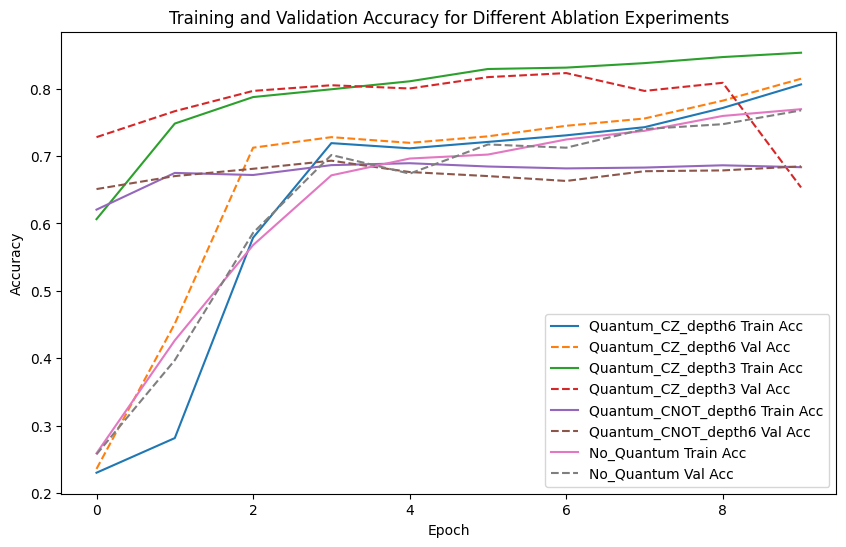

In [10]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pennylane as qml
from sklearn.metrics import accuracy_score

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Global parameters (adjust as needed for your system)
image_size = (224, 224)
num_classes = 6   # update if you change the class_names list
batch_size = 32

# Define a function to build the quantum circuit as a qnode.
def create_quantum_layer(num_qubits, num_layers, variant="CZ"):
    dev = qml.device("default.qubit", wires=num_qubits)
    
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to each qubit
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Embed classical data using RY gates
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Build the entanglement layers
        for layer in range(num_layers):
            # RY rotations
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            # Entanglement block: choose based on variant
            if variant == "CZ":
                # Standard CZ entanglement (ring structure)
                for i in range(num_qubits - 1):
                    qml.CZ(wires=[i, i + 1])
                qml.CZ(wires=[num_qubits - 1, 0])
            elif variant == "CNOT":
                # Alternative variant using CNOT gates in a linear chain
                for i in range(num_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
            # Additional RZ rotations
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotation block: one extra layer before measurement
        for i in range(num_qubits):
            qml.RX(weights[num_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        # Return expectation values as features
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # The weight shapes are determined by: (num_layers + 1, num_qubits, 2)
    weight_shapes = {"weights": (num_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(quantum_circuit, weight_shapes, output_dim=num_qubits, name="quantum_layer")
    return quantum_layer

# Define a helper function to build the full hybrid model
def build_hybrid_model(use_quantum=True, num_qubits=6, num_layers=6, quantum_variant="CZ"):
    """
    Args:
      use_quantum: if False, the model uses the classical backbone only.
      num_qubits: number of qubits (and size of pre-quantum feature dimension)
      num_layers: depth of the quantum circuit (i.e., number of entanglement layers)
      quantum_variant: string to choose gate variant ("CZ" or "CNOT")
    Returns:
      a compiled Keras model ready for training.
    """
    # --- Classical Backbone: InceptionResNetV2 ---
    base_model = InceptionResNetV2(weights='imagenet', include_top=False,
                                    input_shape=(image_size[0], image_size[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)
    
    if use_quantum:
        # Get the quantum layer with specified depth and variant (ablation parameter)
        quantum_layer = create_quantum_layer(num_qubits, num_layers, variant=quantum_variant)
        x = quantum_layer(x)
    else:
        # If quantum component is not used, add an extra dense layer for a fair comparison.
        x = Dense(num_qubits, activation="relu", name="classical_dense")(x)
    
    outputs = Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Here we define the list of experiments (ablation study configurations)
# Each experiment is defined as a dictionary with parameters.
experiments = [
    {"name": "Quantum_CZ_depth6", "use_quantum": True, "num_layers": 6, "quantum_variant": "CZ"},
    {"name": "Quantum_CZ_depth3", "use_quantum": True, "num_layers": 3, "quantum_variant": "CZ"},
    {"name": "Quantum_CNOT_depth6", "use_quantum": True, "num_layers": 6, "quantum_variant": "CNOT"},
    {"name": "No_Quantum", "use_quantum": False}  # purely classical backbone ablation
]

# Dictionary to store results from each experiment
results = {}

# For simplicity, we assume train_generator, val_generator and test_generator are already defined
# (as in your main code earlier) and available in the environment.
# You might want to train each model with a reduced number of epochs for the ablation study.
epochs = 10  # reduce epochs during ablation to shorten experiment time

for exp in experiments:
    print(f"Starting experiment: {exp['name']}")
    # Build the model according to the experiment configuration.
    model = build_hybrid_model(
        use_quantum=exp.get("use_quantum", True),
        num_qubits=6,
        num_layers=exp.get("num_layers", 6),
        quantum_variant=exp.get("quantum_variant", "CZ")
    )
    model.summary()  # Optional: view the model structure
    
    # Define callbacks (simplified for ablation)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]
    
    # Train the model
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print(f"Experiment: {exp['name']} -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    
    # Store the results
    results[exp["name"]] = {
        "history": history.history,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    }

# After all experiments are run, you can analyze and compare results.
print("Ablation study results:")
for name, res in results.items():
    print(f"{name}: Test Accuracy = {res['test_accuracy']:.4f}, Test Loss = {res['test_loss']:.4f}")

# Optionally, you might want to plot accuracy curves for each experiment:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, res in results.items():
    epochs_range = range(len(res["history"]["accuracy"]))
    plt.plot(epochs_range, res["history"]["accuracy"], label=f"{name} Train Acc")
    plt.plot(epochs_range, res["history"]["val_accuracy"], label=f"{name} Val Acc", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy for Different Ablation Experiments")
plt.legend()
plt.show()